# Fig 6.14

Model of E. coli chemotaxis signalling pathway

In [1]:
using ModelingToolkit
using Catalyst
using OrdinaryDiffEq
using Plots
Plots.default(linewidth=2)

In [2]:
rn = @reaction_network begin
    @parameters L(t)
    mm(Am, k1 * BP, KM1), Am => A
    mm(AmL, k2 * BP, KM2), AmL => AL
    km1 * R , A => Am
    km2 * R , AL => AmL
    (k3 * L, km3), Am <--> AmL
    (k4 * L, km4), A <--> AL
    (k5 * Am, km5), B <--> BP
end

Model ##ReactionSystem#256:
Unknowns (6): see unknowns(##ReactionSystem#256)
  Am(t)
  A(t)
  AmL(t)
  AL(t)
  ⋮
Parameters (14): see parameters(##ReactionSystem#256)
  L(t)
  k1
  KM1
  k2
  ⋮

In [3]:
setdefaults!(rn, [
    :Am => 0.0360,
    :AmL => 1.5593,
    :A => 0.0595,
    :AL => 0.3504,
    :B => 0.7356,
    :BP => 0.2644,
    :k1 => 200,
    :k2 => 1,
    :k3 => 1,
    :km1 => 1,
    :km2 => 1,
    :km3 => 1,
    :k5 => 0.05,
    :km5 => 0.005,
    :k4 => 1,
    :km4 => 1,
    :KM1 => 1,
    :KM2 => 1,
    :R => 1,
    :L => 20
])

@unpack L = rn
osys = convert(ODESystem, rn; remove_conserved = true, discrete_events = [[10] => [L ~ 40], [30] => [L ~ 80]]) |> complete

┌ Warning: You are creating a system or problem while eliminating conserved quantities. Please note,
│         due to limitations / design choices in ModelingToolkit if you use the created system to
│         create a problem (e.g. an `ODEProblem`), or are directly creating a problem, you *should not*
│         modify that problem's initial conditions for species (e.g. using `remake`). Changing initial
│         conditions must be done by creating a new Problem from your reaction system or the
│         ModelingToolkit system you converted it into with the new initial condition map.
│         Modification of parameter values is still possible, *except* for the modification of any
│         conservation law constants (Γ), which is not possible. You might
│         get this warning when creating a problem directly.
│ 
│         You can remove this warning by setting `remove_conserved_warn = false`.
└ @ Catalyst ~/.julia/packages/Catalyst/48wH3/src/reactionsystem_conversions.jl:456


Model ##ReactionSystem#256:
Equations (4):
  4 standard: see equations(##ReactionSystem#256)
Unknowns (4): see unknowns(##ReactionSystem#256)
  Am(t) [defaults to 0.036]
  A(t) [defaults to 0.0595]
  AmL(t) [defaults to 1.5593]
  B(t) [defaults to 0.7356]
Parameters (16): see parameters(##ReactionSystem#256)
  km1 [defaults to 1.0]
  km3 [defaults to 1.0]
  Γ[1] [defaults to AmL(t) + Am(t) + A(t) + AL(t)]
  km2 [defaults to 1.0]
  ⋮
Observed (2): see observed(##ReactionSystem#256)

In [4]:
observed(osys)

2-element Vector{Symbolics.Equation}:
 AL(t) ~ -AmL(t) - Am(t) - A(t) + Γ[1]
 BP(t) ~ -B(t) + Γ[2]

In [5]:
equations(osys)

4-element Vector{Symbolics.Equation}:
 Differential(t)(Am(t)) ~ -Catalyst.mm(Am(t), k1*(-B(t) + Γ[2]), KM1) + R*km1 + km3*AmL(t) - k3*Am(t)*L(t)
 Differential(t)(A(t)) ~ Catalyst.mm(Am(t), k1*(-B(t) + Γ[2]), KM1) - R*km1 + km4*(-AmL(t) - Am(t) - A(t) + Γ[1]) - k4*A(t)*L(t)
 Differential(t)(AmL(t)) ~ -Catalyst.mm(AmL(t), k2*(-B(t) + Γ[2]), KM2) + R*km2 - km3*AmL(t) + k3*Am(t)*L(t)
 Differential(t)(B(t)) ~ km5*(-B(t) + Γ[2]) - k5*Am(t)*B(t)

In [6]:
tend = 50.0
prob = ODEProblem(osys, [], tend);
sol = solve(prob)

┌ Warning: Initialization system is overdetermined. 2 equations for 0 unknowns. Initialization will default to using least squares. `SCCNonlinearProblem` can only be used for initialization of fully determined systems and hence will not be used here. To suppress this warning pass warn_initialize_determined = false. To make this warning into an error, pass fully_determined = true
└ @ ModelingToolkit ~/.julia/packages/ModelingToolkit/CvDvM/src/systems/diffeqs/abstractodesystem.jl:1446


retcode: Success
Interpolation: 3rd order Hermite
t: 105-element Vector{Float64}:
  0.0
  0.0
  0.05968737770312525
  0.08662460033554424
  0.12694391787581313
  0.16950791095146842
  0.2229946265995895
  0.28241446330146397
  0.3413393099804022
  0.39629908274591924
  ⋮
 34.00753385281169
 34.97233280943664
 36.03648174376251
 37.33758933001082
 38.83290672234507
 40.68813264306904
 42.956499116505604
 45.95257092480216
 50.0
u: 105-element Vector{Vector{Float64}}:
 [0.036, 0.0595, 1.5593, 0.7356]
 [0.036, 0.0595, 1.5593, 0.7356]
 [0.03595027525385366, 0.05953953220886678, 1.5593219305751664, 0.7355997935085642]
 [0.03601289608672456, 0.05947514303222826, 1.5593068605221378, 0.7355997452996131]
 [0.036022073388818514, 0.05946463801131664, 1.5593088555837615, 0.7355996283853471]
 [0.03602437773678273, 0.05946174455183917, 1.5593129524853817, 0.7355995010070753]
 [0.036023848727154105, 0.05946199844888866, 1.5593188688752477, 0.7355993390621877]
 [0.036020335741447994, 0.059465416830149

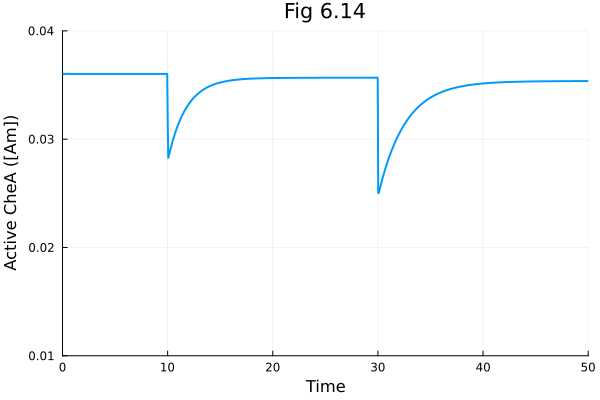

In [7]:
plot(sol, idxs=[osys.Am], title="Fig 6.14", xlabel="Time", ylabel="Active CheA ([Am])", ylims=(0.01, 0.04), legend=false)

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*